In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [275]:
name = 'binary2'

In [276]:
deepseek_df = pd.read_csv(f'deepseekR1_ZS_{name}.csv')
gemma_df = pd.read_csv(f'gemma_ZS_{name}.csv')
llama_df = pd.read_csv(f'llama_ZS_{name}.csv')
openai_df = pd.read_csv(f'openai_ZS_{name}.csv')
gemini_df = pd.read_csv(f'gemini_ZS_{name}.csv')

sklearn_df = pd.read_csv(f'results_sklearn_{name}.csv')
bert_df = pd.read_csv(f'bert_{name}.csv')

In [277]:
size = len(deepseek_df)
size

1066

In [278]:
def results_llm(df):
    error_count = len(df[df['prediction'] == 'error'])
    error_rate = error_count / len(df)

    print(f"Total predictions: {len(df)}")
    print(f"Error count: {error_count}")
    print(f"Error rate: {error_rate:.2%}")

    try:
        df = df[df['prediction_post_processed'] != 'error']
    except:
        df = df[df['prediction'] != 'error']

    y_true = df['label']

    try:
        y_pred = df['prediction_post_processed']
    except:
        y_pred = df['prediction']
        

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    try:
        mean_ram_usage = df['ram_usage'].mean()
        mean_vram_usage = df['vram_usage'].mean()
    except:
        mean_ram_usage = 0
        mean_vram_usage = 0
    
    try:
        mean_time = df['response_time'].mean()
    except:
        mean_time = df['request_time'].mean()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time
    }

    print(results)

    return results

In [279]:
print("DeepSeek results:")
results_deepseek = results_llm(deepseek_df)
print("\n")
print("Gemma results:")
results_gemma = results_llm(gemma_df)
print("\n")
print("Llama results:")
results_llama = results_llm(llama_df)
print("\n")
print("OpenAI results:")
results_openai = results_llm(openai_df)
print("\n")
print("Gemini results:")
results_gemini = results_llm(gemini_df)
print("\n")

DeepSeek results:
Total predictions: 1066
Error count: 161
Error rate: 15.10%
{'accuracy': 0.7723756906077348, 'precision': np.float64(0.7858315884550642), 'recall': np.float64(0.772014221944382), 'f1_score': np.float64(0.7695048613789898), 'mean_ram_usage': np.float64(79.66621633287293), 'mean_vram_usage': np.float64(2325.721546961326), 'mean_response_time': np.float64(4.2829511602939165)}


Gemma results:
Total predictions: 1066
Error count: 1
Error rate: 0.09%
{'accuracy': 0.8516431924882629, 'precision': np.float64(0.8698546272178811), 'recall': np.float64(0.8515390258009), 'f1_score': np.float64(0.8497675132849551), 'mean_ram_usage': np.float64(102.95927230046948), 'mean_vram_usage': np.float64(5241.961502347418), 'mean_response_time': np.float64(2.3262948824206426)}


Llama results:
Total predictions: 1066
Error count: 7
Error rate: 0.66%
{'accuracy': 0.8734655335221907, 'precision': np.float64(0.8820730977943751), 'recall': np.float64(0.8736785225132683), 'f1_score': np.float64(

In [280]:
def results_sklearn(df):
    
    grouped = df.groupby(['vectorizer', 'model', 'params'])

    df['average_f1'] = df.filter(like='f1_class_').mean(axis=1)
    df['average_precision'] = df.filter(like='precision_class_').mean(axis=1)
    df['average_recall'] = df.filter(like='recall_class_').mean(axis=1)
    
    mean_f1 = grouped['average_f1'].mean().reset_index()
    
    best_model = mean_f1.loc[mean_f1['average_f1'].idxmax()]
    
    best_config_df = df[(df['vectorizer'] == best_model['vectorizer']) &
                        (df['model'] == best_model['model']) &
                        (df['params'] == best_model['params'])]
    
    accuracy = best_config_df['accuracy'].mean()
    f1 = best_config_df['average_f1'].mean()
    precision = best_config_df['average_precision'].mean()
    recall = best_config_df['average_recall'].mean()
    mean_ram_usage = best_config_df['peak_memory_prediction'].mean()
    mean_vram_usage = 0
    pred_time = best_config_df['prediction_time'].mean()

    std_accuracy = best_config_df['accuracy'].std()
    std_f1 = best_config_df['average_f1'].std()
    std_precision = best_config_df['average_precision'].std()
    std_recall = best_config_df['average_recall'].std()
    std_ram_usage = best_config_df['peak_memory_prediction'].std()
    std_vram_usage = 0
    std_pred_time = best_config_df['prediction_time'].std()


    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': pred_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_mean_ram_usage': std_ram_usage,
        'std_mean_vram_usage': std_vram_usage,
        'std_mean_response_time': std_pred_time / size
    }
    

    return results, results_std

In [281]:
results_sklearn_model = results_sklearn(sklearn_df)[0]

In [282]:
def results_bert(df):

    df['average_test_f1'] = df['test_f1s'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_precisions'] = df['test_precisions'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_recalls'] = df['test_recalls'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )

    accuracy = df['test_acc'].mean()
    precision = df['average_test_precisions'].mean()
    recall = df['average_test_recalls'].mean()
    f1 = df['average_test_f1'].mean()
    mean_ram_usage = df['max_memory_usage_test'].mean()
    mean_vram_usage = df['max_vram_usage_test'].mean()
    mean_time = df['total_test_time'].mean()

    # now get standar deviation
    std_accuracy = df['test_acc'].std()
    std_precision = df['average_test_precisions'].std()
    std_recall = df['average_test_recalls'].std()
    std_f1 = df['average_test_f1'].std()
    std_ram_usage = df['max_memory_usage_test'].std()
    std_vram_usage = df['max_vram_usage_test'].std()
    std_time = df['total_test_time'].std()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_ram_usage': std_ram_usage,
        'std_vram_usage': std_vram_usage,
        'std_response_time': std_time / size
    }

    
    return results, results_std

results_bert_model = results_bert(bert_df)[0]
results_bert_model

{'accuracy': np.float64(0.8524077548467792),
 'precision': np.float64(0.8532367955384424),
 'recall': np.float64(0.8524077548467792),
 'f1_score': np.float64(0.8523250689227759),
 'mean_ram_usage': np.float64(1324.19921875),
 'mean_vram_usage': np.float64(1704.6725260416667),
 'mean_response_time': np.float64(0.009435264383985972)}

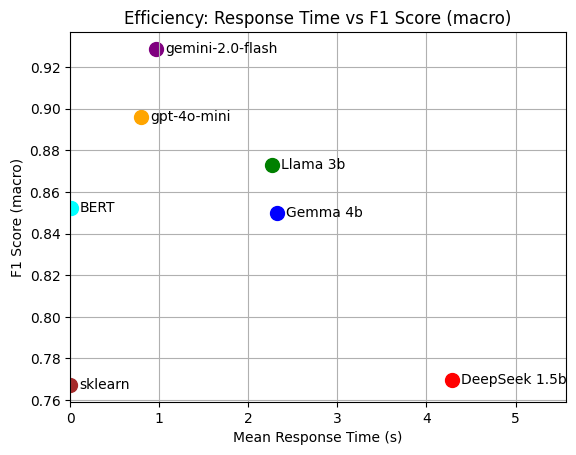

In [ ]:
def plot_results(results):
    models = ['DeepSeek 1.5b', 'Gemma 4b', 'Llama 3b', 'gpt-4o-mini', 'gemini-2.0-flash', 'BERT', 'sklearn']
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'brown']
    
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]
    
    offset = 0.1
    
    for i in range(len(models)):
        plt.scatter(mean_response_times[i], f1_scores[i], color=colors[i], s=100)
        plt.text(mean_response_times[i] + offset, f1_scores[i], models[i], ha='left', va='center')
    
    xlim = max(mean_response_times)

    plt.xlim(left = 0, right = xlim + xlim * 0.3)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency: Response Time vs F1 Score (macro)')
    plt.grid(True)
    
    plt.show()

plot_results([results_deepseek, results_gemma, results_llama, results_openai, results_gemini, results_bert_model, results_sklearn_model])

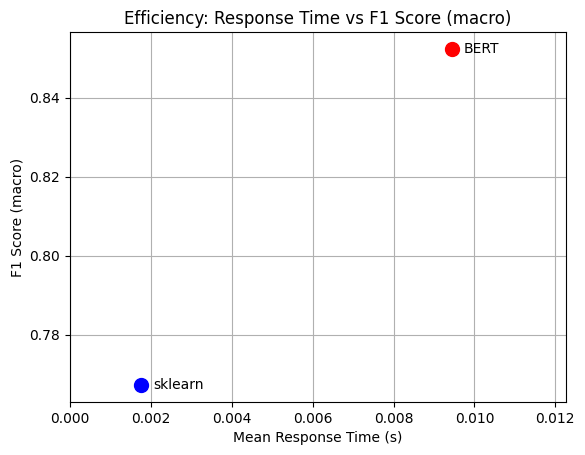

In [306]:
def plot_results(results):
    models = ['BERT', 'sklearn']
    colors = ['red', 'blue']
    
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]
    
    offset = 0.0003
    
    for i in range(len(models)):
        plt.scatter(mean_response_times[i], f1_scores[i], color=colors[i], s=100)
        plt.text(mean_response_times[i] + offset, f1_scores[i], models[i], ha='left', va='center')
    
    xlim = max(mean_response_times)

    plt.xlim(left = 0, right = xlim + xlim * 0.3)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency: Response Time vs F1 Score (macro)')
    plt.grid(True)
    
    plt.show()

plot_results([results_bert_model, results_sklearn_model])